# 05 - Feature Engineering, Leakage-Safe Feature Selection, and Preprocessing Design

This notebook converts the cleaned credit-risk dataset into a modelling-ready, leakage-reviewed dataset for the next modelling phase.

The objective is to demonstrate the type of work expected in Canadian finance analytics roles: feature engineering, feature governance, leakage control, train/validation/test discipline, preprocessing design, and explainable documentation.

This notebook does **not** fit models. It also does **not** fit imputers, encoders, scalers, target encoders, resampling methods, or transformations on the full dataset. Those steps belong in Notebook 06 inside model pipelines fitted on the training split only.

## Notebook 05 responsibilities

| Area | What this notebook does | What it avoids |
|---|---|---|
| Feature engineering | Creates deterministic borrower, loan, affordability, banding, and quality features | Does not learn cutpoints from the target |
| Leakage control | Separates baseline, monitoring-only, proxy-sensitive, and timing-review features | Does not include repayment-derived leakage fields in the baseline dataset |
| Feature selection design | Creates train-only univariate screening diagnostics | Does not use validation/test data to select features |
| Preprocessing design | Documents numeric, binary, nominal, and ordinal preprocessing groups | Does not fit encoders/scalers/imputers yet |
| Modelling readiness | Saves unencoded modelling dataset with split labels | Does not train or tune models |

## Business questions this notebook answers

| Business / risk question | Output created |
|---|---|
| Which features are safe for a conservative baseline default model? | `05_feature_leakage_and_usage_policy.csv` |
| Which fields are monitoring-only because of leakage risk? | Feature policy and excluded-field review |
| Which features were engineered and from which source fields? | `05_feature_lineage.csv` |
| Which variables should be numeric, binary, nominal, or ordinal in the model pipeline? | `05_preprocessing_pipeline_design.csv` and `05_preprocessing_column_groups.json` |
| Are train, validation, and test default rates stable? | `05_modeling_split_distribution.csv` |
| Which feature groups need imputation after split? | `05_modeling_feature_missingness_by_split.csv` |
| Which categories are rare and need pipeline treatment? | `05_rare_category_review.csv` |
| Which variables have training-only univariate signal? | `05_train_only_univariate_feature_screening.csv` |
| Which numeric features may be redundant for linear models? | `05_multicollinearity_review.csv` |

In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.options.display.float_format = "{:,.4f}".format

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

CLEANED_PATH_CANDIDATES = [
    PROCESSED_DIR / "credit_risk_cleaned.csv",
    Path("/mnt/data/credit_risk_cleaned.csv"),  # fallback for this ChatGPT execution environment
]

CLEANED_PATH = next((p for p in CLEANED_PATH_CANDIDATES if p.exists()), None)
if CLEANED_PATH is None:
    raise FileNotFoundError("credit_risk_cleaned.csv was not found. Run Notebook 03 / run_cleaning_pipeline.py first.")

from credit_risk.features.engineering import (
    TARGET_COL,
    ID_COLS,
    SPLIT_COL,
    REPAYMENT_MONITORING_FIELDS,
    SENSITIVE_OR_HIGH_RISK_PROXY_FIELDS,
    TIMING_REVIEW_FIELDS,
    save_feature_engineering_outputs,
)

CLEANED_PATH

WindowsPath('D:/Banking and Finance/Projects/canadian-retail-credit-risk-xai/data/processed/credit_risk_cleaned.csv')

## Load cleaned dataset

The input should be the output from Notebook 03. At this stage, rows should already be cleaned, audited, and documented, but final modelling transformations should not yet be fitted.

In [2]:
df = pd.read_csv(CLEANED_PATH, low_memory=False)

load_summary = pd.DataFrame({
    "metric": [
        "row_count",
        "column_count",
        "target_present",
        "default_rate_pct",
        "record_key_duplicate_count",
        "source_file",
    ],
    "value": [
        df.shape[0],
        df.shape[1],
        TARGET_COL in df.columns,
        round(df[TARGET_COL].mean() * 100, 4) if TARGET_COL in df.columns else np.nan,
        int(df.duplicated(ID_COLS).sum()) if set(ID_COLS).issubset(df.columns) else "missing_record_keys",
        str(CLEANED_PATH),
    ],
})

load_summary.to_csv(TABLE_DIR / "05_load_summary.csv", index=False)
load_summary

,metric,value
0,row_count,134417
1,column_count,46
2,target_present,True
3,default_rate_pct,9.0413
4,record_key_duplicate_count,0
5,source_file,D:\Banking and Finance\Projects\canadian-retail-credit-risk-xai\data\processed\credit_risk_cleaned.csv


## Build and save feature-engineering artifacts

The function below creates all Notebook 05 outputs in one reproducible step. It saves both the modelling dataset and the audit tables that explain every feature decision.

In [3]:
artifacts = save_feature_engineering_outputs(
    cleaned_df=df,
    processed_dir=PROCESSED_DIR,
    table_dir=TABLE_DIR,
    random_state=42,
)

{k: v.shape for k, v in artifacts.items() if isinstance(v, pd.DataFrame)}

{'engineered_df': (134417, 58),
 'modeling_df': (134417, 44),
 'feature_policy': (58, 9),
 'feature_catalog': (40, 11),
 'feature_lineage': (13, 4),
 'preprocessing_plan': (5, 5),
 'ordinal_mapping_plan': (7, 5),
 'split_distribution': (3, 5),
 'missingness_by_split': (120, 5),
 'rare_category_review': (57, 6),
 'train_only_univariate_screening': (40, 11),
 'multicollinearity_review': (29, 5),
 'feature_family_summary': (7, 4),
 'qa_checks': (6, 3),
 'output_manifest': (17, 3)}

## Executive feature-engineering summary

The table below summarizes the key outputs that should be reviewed before moving to model training.

In [4]:
modeling_df = artifacts["modeling_df"]
feature_policy = artifacts["feature_policy"]
feature_catalog = artifacts["feature_catalog"]

feature_cols = [c for c in modeling_df.columns if c not in ID_COLS + [TARGET_COL, SPLIT_COL]]
numeric_feature_count = modeling_df[feature_cols].select_dtypes(include="number").shape[1]
categorical_feature_count = len(feature_cols) - numeric_feature_count

executive_summary = pd.DataFrame({
    "metric": [
        "cleaned_input_rows",
        "cleaned_input_columns",
        "modeling_rows",
        "modeling_columns",
        "modeling_feature_count",
        "numeric_feature_count",
        "categorical_feature_count",
        "default_rate_pct",
        "excluded_repayment_leakage_fields_present_in_modeling",
        "excluded_high_risk_proxy_fields_present_in_modeling",
    ],
    "value": [
        df.shape[0],
        df.shape[1],
        modeling_df.shape[0],
        modeling_df.shape[1],
        len(feature_cols),
        numeric_feature_count,
        categorical_feature_count,
        round(modeling_df[TARGET_COL].mean() * 100, 4),
        sorted(set(REPAYMENT_MONITORING_FIELDS).intersection(modeling_df.columns)),
        sorted(set(SENSITIVE_OR_HIGH_RISK_PROXY_FIELDS).intersection(modeling_df.columns)),
    ],
})

executive_summary.to_csv(TABLE_DIR / "05_executive_feature_engineering_summary.csv", index=False)
executive_summary

,metric,value
0,cleaned_input_rows,134417
1,cleaned_input_columns,46
2,modeling_rows,134417
3,modeling_columns,44
4,modeling_feature_count,40
5,numeric_feature_count,29
6,categorical_feature_count,11
7,default_rate_pct,9.0413
8,excluded_repayment_leakage_fields_present_in_modeling,[]
9,excluded_high_risk_proxy_fields_present_in_modeling,[]


## Feature-use policy

This is the governance backbone of the notebook. It explains which columns are included, excluded, monitoring-only, or require timing confirmation before modelling.

In [5]:
feature_policy_summary = (
    feature_policy
    .groupby(["decision", "baseline_model_policy"], dropna=False)
    .agg(feature_count=("feature", "count"))
    .reset_index()
    .sort_values("feature_count", ascending=False)
)

feature_policy_summary

,decision,baseline_model_policy,feature_count
4,include_conservative_baseline,include_in_baseline,37
6,monitoring_only_leakage_risk,exclude_from_baseline,7
0,audit_governance_only,exclude_from_baseline,4
5,include_with_governance_monitoring,include_with_monitoring,3
1,audit_key_only,exclude_from_model,2
2,audit_or_future_grouping_only,exclude_from_baseline,2
3,candidate_requires_timing_confirmation,review_before_modelling,2
7,target_only,exclude_from_features,1


In [6]:
# Features excluded from the conservative baseline model
excluded_or_review_features = (
    feature_policy
    .query("baseline_model_policy not in ['include_in_baseline', 'include_with_monitoring']")
    .sort_values(["baseline_model_policy", "feature_family", "feature"])
    .reset_index(drop=True)
)

excluded_or_review_features[["feature", "feature_family", "decision", "baseline_model_policy", "reason"]].head(50)

,feature,feature_family,decision,baseline_model_policy,reason
0,industry,high_cardinality_or_encrypted,audit_or_future_grouping_only,exclude_from_baseline,High-cardinality/encrypted field is not explainable enough for first baseline model.
1,role,high_cardinality_or_encrypted,audit_or_future_grouping_only,exclude_from_baseline,High-cardinality/encrypted field is not explainable enough for first baseline model.
2,interest_received,repayment_monitoring,monitoring_only_leakage_risk,exclude_from_baseline,Repayment-derived/post-origination information may leak outcome timing.
3,interest_to_amount_ratio,repayment_monitoring,monitoring_only_leakage_risk,exclude_from_baseline,Repayment-derived/post-origination information may leak outcome timing.
4,payment_to_amount_ratio,repayment_monitoring,monitoring_only_leakage_risk,exclude_from_baseline,Repayment-derived/post-origination information may leak outcome timing.
5,principal_exceeds_amount_flag,repayment_monitoring,monitoring_only_leakage_risk,exclude_from_baseline,Repayment-derived/post-origination information may leak outcome timing.
6,principal_to_amount_ratio,repayment_monitoring,monitoring_only_leakage_risk,exclude_from_baseline,Repayment-derived/post-origination information may leak outcome timing.
7,received_principal,repayment_monitoring,monitoring_only_leakage_risk,exclude_from_baseline,Repayment-derived/post-origination information may leak outcome timing.
8,total_payment,repayment_monitoring,monitoring_only_leakage_risk,exclude_from_baseline,Repayment-derived/post-origination information may leak outcome timing.
9,gender,sensitive_or_high_risk_proxy,audit_governance_only,exclude_from_baseline,Sensitive or high-risk proxy field retained for fairness/governance monitoring.


## Engineered feature lineage

Feature lineage is important for model risk review because it shows whether a feature is raw, engineered, deterministic, or potentially dependent on unavailable information.

In [7]:
artifacts["feature_lineage"].head(30)

,engineered_feature,source_columns,transformation_type,business_rationale
0,loan_to_income_ratio,"amount, total_income_pa",existing_cleaning_feature,Retained from cleaning because it is a core affordability measure.
1,income_to_loan_buffer,"total_income_pa, amount",difference,Captures remaining annual-income buffer after loan amount.
2,loan_to_income_missing_flag,"amount, total_income_pa",binary_flag,Identifies unavailable affordability ratio caused by missing or invalid inputs.
3,loan_amount_band,amount,fixed_business_band,Supports exposure segmentation without learning cutpoints from the target.
4,income_band,total_income_pa,fixed_business_band,Enables income-risk segmentation with stable business thresholds.
5,interest_rate_band,interest_rate,fixed_business_band,Groups risk-based pricing levels for monitoring and modelling.
6,high_interest_flag,interest_rate,binary_flag,Flags relatively expensive loans that may reflect higher risk pricing.
7,tenure_band,tenure_years,fixed_business_band,Supports term-risk segmentation.
8,long_tenure_flag,tenure_years,binary_flag,Identifies longer-term loans that may carry different exposure duration.
9,loan_to_income_band,loan_to_income_ratio,fixed_business_band,Groups affordability burden using fixed thresholds.


## Baseline modelling feature catalogue

This catalogue is the handoff from feature engineering to model training. It contains only leakage-reviewed modelling features, not repayment-derived monitoring-only variables.

In [8]:
feature_catalog.head(60)

,feature,dtype,feature_family,non_null_count,missing_count,missing_pct,unique_values,example_values,decision,baseline_model_policy,reason
0,income_to_loan_buffer,float64,affordability,106779,27638,20.5614,88823,"69116.0, 5489.0, 87711.0, 676.0, 34748.0",include_conservative_baseline,include_in_baseline,"Deterministic, row-level, explainable feature not marked as leakage or high-risk proxy."
1,loan_to_income_ratio,float64,affordability,106779,27638,20.5614,104531,"0.447072, 0.910016393442623, 0.12289, 0.9774666666666668, 0.4654153846153846",include_conservative_baseline,include_in_baseline,"Deterministic, row-level, explainable feature not marked as leakage or high-risk proxy."
2,total_income_pa,float64,affordability,134417,0,0.0000,11380,"125000.0, 61000.0, 100000.0, 30000.0, 65000.0",include_conservative_baseline,include_in_baseline,"Deterministic, row-level, explainable feature not marked as leakage or high-risk proxy."
3,has_broad_data_quality_issue,int64,baseline_candidate,134417,0,0.0000,2,"0, 1",include_conservative_baseline,include_in_baseline,"Deterministic, row-level, explainable feature not marked as leakage or high-risk proxy."
4,has_core_data_quality_issue,int64,baseline_candidate,134417,0,0.0000,2,"0, 1",include_conservative_baseline,include_in_baseline,"Deterministic, row-level, explainable feature not marked as leakage or high-risk proxy."
5,income_band,object,business_band_feature,134417,0,0.0000,5,"100K-150K, 50K-75K, 75K-100K, <=50K, >150K",include_conservative_baseline,include_in_baseline,"Deterministic, row-level, explainable feature not marked as leakage or high-risk proxy."
6,interest_rate_band,object,business_band_feature,134417,0,0.0000,5,"8%-12%, 16%-20%, 12%-16%, <=8%, >20%",include_conservative_baseline,include_in_baseline,"Deterministic, row-level, explainable feature not marked as leakage or high-risk proxy."
7,loan_amount_band,object,business_band_feature,134417,0,0.0000,6,"50K-100K, 10K-25K, 25K-50K, >100K, <=10K",include_conservative_baseline,include_in_baseline,"Deterministic, row-level, explainable feature not marked as leakage or high-risk proxy."
8,loan_to_income_band,object,business_band_feature,134417,0,0.0000,6,"25%-50%, 50%-100%, 10%-25%, >100%, <=10%",include_conservative_baseline,include_in_baseline,"Deterministic, row-level, explainable feature not marked as leakage or high-risk proxy."
9,tenure_band,object,business_band_feature,134417,0,0.0000,2,">5Y, 3Y-5Y",include_conservative_baseline,include_in_baseline,"Deterministic, row-level, explainable feature not marked as leakage or high-risk proxy."


## Feature family summary

This table shows whether the modelling dataset is balanced across loan terms, affordability, employment, data-quality flags, business bands, and governance-monitored fields.

In [9]:
artifacts["feature_family_summary"]

,feature_family,baseline_model_policy,feature_count,max_missing_pct
3,data_quality_or_binary_flag,include_in_baseline,20,0.0000
2,business_band_feature,include_in_baseline,5,0.0000
5,loan_terms,include_in_baseline,4,20.5614
0,affordability,include_in_baseline,3,20.5614
4,employment_profile,include_in_baseline,3,0.0000
6,proxy_governance_review,include_with_monitoring,3,0.0000
1,baseline_candidate,include_in_baseline,2,0.0000


## Stratified train / validation / test split

Because the dataset does not contain a reliable observation date, the project uses a stratified random 70/15/15 split for modelling readiness. In a real bank implementation, an out-of-time validation set should be preferred when application or performance dates are available.

In [10]:
split_distribution = artifacts["split_distribution"]
split_distribution

,split,row_count,row_share_pct,default_count,default_rate_pct
0,train,94091,69.9993,8507,9.0412
1,validation,20163,15.0003,1823,9.0413
2,test,20163,15.0003,1823,9.0413


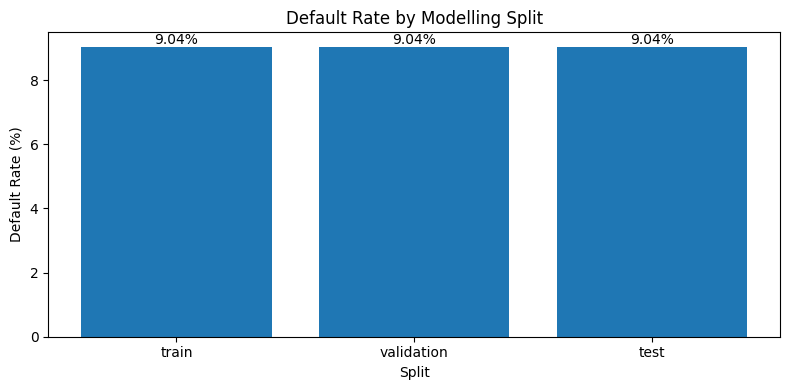

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(split_distribution["split"], split_distribution["default_rate_pct"])
ax.set_title("Default Rate by Modelling Split")
ax.set_xlabel("Split")
ax.set_ylabel("Default Rate (%)")
for idx, value in enumerate(split_distribution["default_rate_pct"]):
    ax.text(idx, value, f"{value:.2f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## Missingness by modelling split

This confirms which features require imputation inside Notebook 06 pipelines. Imputation is intentionally not fitted here.

In [12]:
missingness_by_split = artifacts["missingness_by_split"]
missingness_top = (
    missingness_by_split
    .groupby("feature", as_index=False)
    .agg(max_missing_pct=("missing_pct", "max"), max_missing_count=("missing_count", "max"))
    .sort_values("max_missing_pct", ascending=False)
)
missingness_top.head(25)

,feature,max_missing_pct,max_missing_count
0,amount,20.7799,19552
17,income_to_loan_buffer,20.7799,19552
28,loan_to_income_ratio,20.7799,19552
21,interest_rate_band,0.0000,0
23,is_verified_missing_flag,0.0000,0
24,loan_amount_band,0.0000,0
25,loan_category,0.0000,0
26,loan_to_income_band,0.0000,0
27,loan_to_income_missing_flag,0.0000,0
29,long_tenure_flag,0.0000,0


## Preprocessing pipeline design

This is a design artifact for Notebook 06. The key rule is that every fitted transformation must be fit only on the training split.

In [13]:
artifacts["preprocessing_plan"]

,feature_group,feature_count,features,preprocessing_design,fit_stage
0,continuous_numeric_features,9,"amount, interest_rate, tenure_years, total_income_pa, dependents, loan_to_income_ratio, broad_data_quality_issue_cou...",SimpleImputer(strategy='median'); optional scaling only for linear models,fit_on_training_split_only_inside_model_pipeline
1,binary_indicator_features,20,"amount_missing_raw_flag, amount_non_positive_flag, industry_placeholder_zero_flag, work_experience_placeholder_zero_...",SimpleImputer(strategy='most_frequent'); keep as 0/1,fit_on_training_split_only_inside_model_pipeline
2,nominal_categorical_features,4,"loan_category, employment_type, home, is_verified","SimpleImputer(strategy='constant', fill_value='Unknown') + OneHotEncoder(handle_unknown='ignore')",fit_on_training_split_only_inside_model_pipeline
3,ordinal_categorical_features,7,"tier_of_employment, work_experience, income_band, loan_amount_band, interest_rate_band, tenure_band, loan_to_income_...","SimpleImputer(strategy='constant', fill_value='Unknown') + OrdinalEncoder with documented order",fit_on_training_split_only_inside_model_pipeline
4,class_imbalance_strategy,0,target: defaulter,"class_weight, threshold tuning, or training-only resampling; never resample validation/test",model_training_only


In [14]:
artifacts["ordinal_mapping_plan"]

,feature,recommended_encoder,ordered_values,observed_unmapped_values,fit_stage
0,tier_of_employment,"OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)",Unknown | A | B | C | D | E | F,G,fit_on_training_split_only
1,work_experience,"OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)",Unknown | <1 | 1-2 | 2-3 | 3-5 | 5-10 | 10+,,fit_on_training_split_only
2,income_band,"OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)",Missing | <=50K | 50K-75K | 75K-100K | 100K-150K | >150K,,fit_on_training_split_only
3,loan_amount_band,"OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)",Missing | <=10K | 10K-25K | 25K-50K | 50K-100K | >100K,,fit_on_training_split_only
4,interest_rate_band,"OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)",Missing | <=8% | 8%-12% | 12%-16% | 16%-20% | >20%,,fit_on_training_split_only
5,tenure_band,"OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)",Missing | <=1Y | 1Y-3Y | 3Y-5Y | >5Y,,fit_on_training_split_only
6,loan_to_income_band,"OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)",Missing | <=10% | 10%-25% | 25%-50% | 50%-100% | >100%,,fit_on_training_split_only


## Rare-category review

Rare categories should be handled inside the model pipeline using grouping or `handle_unknown='ignore'`. They should not be grouped using validation/test information.

In [15]:
rare_category_review = artifacts["rare_category_review"]
rare_category_review.query("rare_category_flag == True").head(30)

,feature,category_value,row_count,share_pct,rare_category_flag,recommended_action
6,home,Other/None,88,0.0655,True,group_or_handle_unknown_in_pipeline
48,tier_of_employment,F,1252,0.9314,True,group_or_handle_unknown_in_pipeline
49,tier_of_employment,G,256,0.1905,True,group_or_handle_unknown_in_pipeline


## Train-only univariate feature screening

This section performs supervised feature-screening diagnostics on the **training split only**. These diagnostics are not final feature selection. They are a leakage-safe review to prioritize modelling and validation attention.

In [16]:
train_only_screening = artifacts["train_only_univariate_screening"]
train_only_screening.head(40)

,feature,feature_type,screening_test,non_default_mean_or_rate,default_mean_or_rate,effect_size,p_value,leakage_safe_scope,highest_risk_category_on_train,absolute_effect_size,screening_recommendation
0,interest_rate,numeric_or_binary,mann_whitney_u_and_cohens_d,11.7985,14.2132,0.6306,0.0000,training_split_only,NaN,0.6306,stronger_univariate_signal_review_in_model
1,total_income_pa,numeric_or_binary,mann_whitney_u_and_cohens_d,"73,498.8256","64,025.0144",-0.1912,0.0000,training_split_only,NaN,0.1912,stronger_univariate_signal_review_in_model
2,interest_rate_band,categorical,chi_square_and_cramers_v,NaN,0.2162,0.1786,0.0000,training_split_only,>20%,0.1786,stronger_univariate_signal_review_in_model
3,amount,numeric_or_binary,mann_whitney_u_and_cohens_d,"139,676.9429","114,558.7854",-0.1740,0.0000,training_split_only,NaN,0.1740,stronger_univariate_signal_review_in_model
4,high_interest_flag,numeric_or_binary,chi_square_binary_flag,0.1451,0.3407,0.1519,0.0000,training_split_only,NaN,0.1519,stronger_univariate_signal_review_in_model
5,loan_to_income_band,categorical,chi_square_and_cramers_v,NaN,0.1586,0.1252,0.0000,training_split_only,Missing,0.1252,stronger_univariate_signal_review_in_model
6,loan_amount_band,categorical,chi_square_and_cramers_v,NaN,0.1586,0.1251,0.0000,training_split_only,Missing,0.1251,stronger_univariate_signal_review_in_model
7,income_to_loan_buffer,numeric_or_binary,mann_whitney_u_and_cohens_d,"-65,277.4234","-49,417.8413",0.1226,0.0000,training_split_only,NaN,0.1226,stronger_univariate_signal_review_in_model
8,amount_missing_flag,numeric_or_binary,chi_square_binary_flag,0.1922,0.3645,0.1218,0.0000,training_split_only,NaN,0.1218,stronger_univariate_signal_review_in_model
9,loan_to_income_missing_flag,numeric_or_binary,chi_square_binary_flag,0.1922,0.3645,0.1218,0.0000,training_split_only,NaN,0.1218,stronger_univariate_signal_review_in_model


## Multicollinearity review

High-correlation pairs matter most for linear models and interpretability. Tree-based models are less sensitive, but redundant features can still complicate explanations.

In [17]:
multicollinearity_review = artifacts["multicollinearity_review"]
if multicollinearity_review.empty:
    print("No numeric feature pairs exceeded the high-correlation threshold.")
else:
    display(multicollinearity_review.head(30))

,feature_1,feature_2,correlation,abs_correlation,recommended_action
0,employment_type_missing_flag,tier_of_employment_missing_flag,1.0000,1.0000,review_redundancy_before_linear_modeling
1,amount_missing_flag,loan_to_income_missing_flag,1.0000,1.0000,review_redundancy_before_linear_modeling
2,industry_placeholder_zero_flag,work_experience_placeholder_zero_flag,1.0000,1.0000,review_redundancy_before_linear_modeling
3,industry_missing_flag,work_experience_missing_flag,1.0000,1.0000,review_redundancy_before_linear_modeling
4,core_data_quality_issue_count,has_core_data_quality_issue,1.0000,1.0000,review_redundancy_before_linear_modeling
5,tenure_years,long_tenure_flag,1.0000,1.0000,review_redundancy_before_linear_modeling
6,work_experience_placeholder_zero_flag,work_experience_missing_flag,0.9999,0.9999,review_redundancy_before_linear_modeling
7,industry_placeholder_zero_flag,industry_missing_flag,0.9999,0.9999,review_redundancy_before_linear_modeling
8,industry_placeholder_zero_flag,work_experience_missing_flag,0.9999,0.9999,review_redundancy_before_linear_modeling
9,work_experience_placeholder_zero_flag,industry_missing_flag,0.9999,0.9999,review_redundancy_before_linear_modeling


## Feature-engineering QA checks

These checks confirm that row counts are preserved, the target is present, split labels exist, and high-risk leakage/proxy fields are not in the modelling dataset.

In [18]:
qa_checks = artifacts["qa_checks"]
qa_checks

,check,status,value
0,row_count_preserved_after_feature_engineering,pass,"raw=134417, engineered=134417, modeling=134417"
1,target_present,pass,True
2,split_column_present,pass,True
3,record_key_duplicate_count,pass,0
4,no_high_risk_leakage_fields_in_modeling_dataset,pass,
5,no_high_risk_sensitive_proxy_fields_in_modeling_dataset,pass,


## Output manifest

These files are saved for Notebook 06 and for project documentation.

In [19]:
artifacts["output_manifest"]

,artifact,path,exists
0,engineered_dataset,D:\Banking and Finance\Projects\canadian-retail-credit-risk-xai\data\processed\credit_risk_engineered_full_audit_dat...,True
1,modeling_dataset,D:\Banking and Finance\Projects\canadian-retail-credit-risk-xai\data\processed\credit_risk_modeling_dataset.csv,True
2,feature_policy,D:\Banking and Finance\Projects\canadian-retail-credit-risk-xai\reports\tables\05_feature_leakage_and_usage_policy.csv,True
3,feature_catalog,D:\Banking and Finance\Projects\canadian-retail-credit-risk-xai\reports\tables\05_modeling_feature_catalog.csv,True
4,feature_lineage,D:\Banking and Finance\Projects\canadian-retail-credit-risk-xai\reports\tables\05_feature_lineage.csv,True
5,preprocessing_plan,D:\Banking and Finance\Projects\canadian-retail-credit-risk-xai\reports\tables\05_preprocessing_pipeline_design.csv,True
6,ordinal_mapping_plan,D:\Banking and Finance\Projects\canadian-retail-credit-risk-xai\reports\tables\05_ordinal_mapping_plan.csv,True
7,split_distribution,D:\Banking and Finance\Projects\canadian-retail-credit-risk-xai\reports\tables\05_modeling_split_distribution.csv,True
8,missingness_by_split,D:\Banking and Finance\Projects\canadian-retail-credit-risk-xai\reports\tables\05_modeling_feature_missingness_by_sp...,True
9,rare_category_review,D:\Banking and Finance\Projects\canadian-retail-credit-risk-xai\reports\tables\05_rare_category_review.csv,True


## Notebook 05 decisions to carry forward

1. Use `credit_risk_modeling_dataset.csv` as the unencoded, leakage-reviewed modelling dataset.
2. Repayment-derived fields are retained for monitoring but excluded from the conservative baseline model.
3. High-risk sensitive/proxy fields are retained outside the model for governance and fairness review.
4. Timing-review fields such as delinquency history and number of loans should only be used if prediction-time availability is confirmed.
5. Business bands and affordability features are deterministic and may be used in modelling, but encoders must be fit after splitting.
6. Train-only univariate screening can guide modelling review, but final feature selection should be based on validation performance, stability, explainability, and business judgement.
7. Notebook 06 should fit imputers, encoders, scalers, resamplers, and models inside pipelines using the training split only.

Next notebook: **06 - Model Training, Validation, Threshold Selection, and Experiment Tracking**.